In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

import time

## Dataset: Fashion MNIST

Vi använder Fashion MNIST-datasetet som innehåller 28x28 pixlar gråskalebilder av klädesplagg.

Datan delas upp i träningsdata och testdata:

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

In [2]:
# Laddar in Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Delar upp datan i träningsdata och testdata
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

## Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [3]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek
print('x_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('x_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Klassnamn

Eftersom labels i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [4]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

## Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

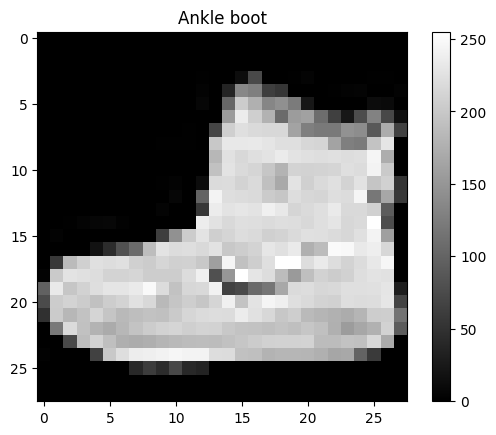

In [5]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

## Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

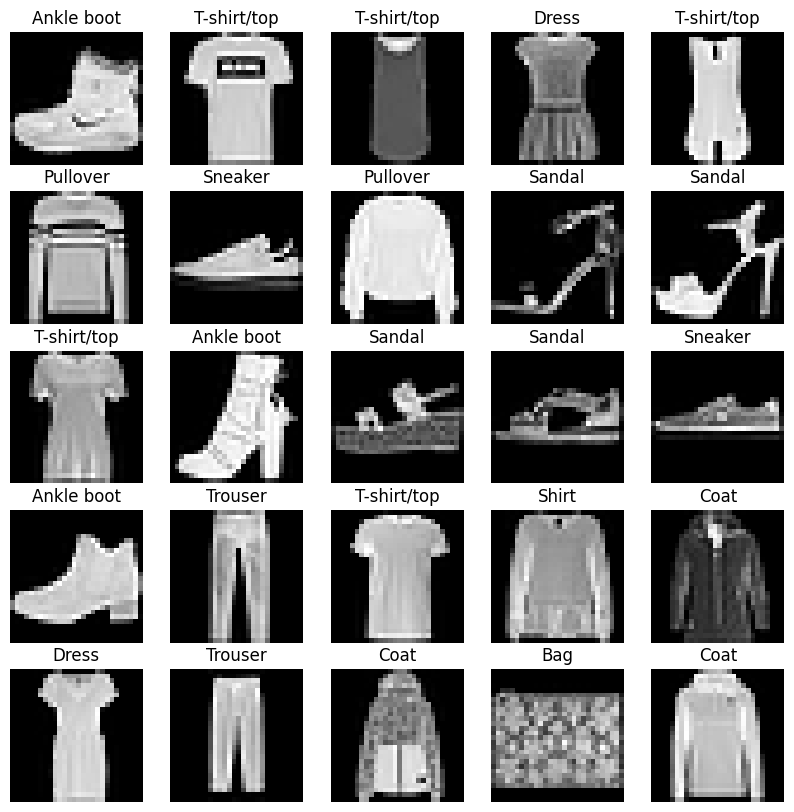

In [6]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

## Klassfördelning

Räknar antal bilder per klass för att se om datasetet är balanserat.

Ett balanserat dataset är viktigt eftersom modellen då tränas jämnt på alla klasser.

In [7]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## Visualisering av klassfördelning

Visualiserar hur många bilder som finns i varje klass med ett stapeldiagram.

Det hjälper oss att snabbt se om någon klass dominerar eller saknas i datan.

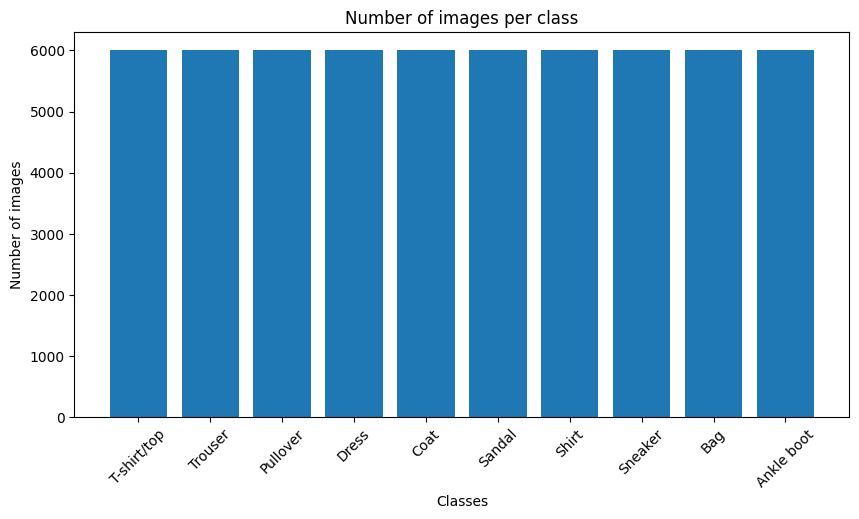

In [8]:
# Visualiserar hur många bilder som finns i varje klass med ett stapeldiagram
plt.figure(figsize=(10,5))

plt.bar(
    [class_names[i] for i in unique],
    counts
)

plt.xticks(rotation=45)
plt.title('Number of images per class')
plt.xlabel('Classes')
plt.ylabel('Number of images')

plt.show()

In [9]:
# Delar upp träningsdata i träning och validering
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [10]:
# Normaliserar bilderna till värden mellan 0 och 1 och gör datatypen till float32
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [11]:
# Anpassar datan till CNN-format (28x28 bilder med 1 färgkanal)
X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Kontrollerar att värdena är normaliserade (0–1)
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test.min(), X_test.max())

# Kontrollerar datans form efter reshape
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (48000, 28, 28, 1)
X_val shape: (12000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [12]:
# Skapar en CNN-modell för bildklassificering
# Modellen tar 28x28 gråskalebilder som input och klassificerar dem i 10 klasser
def build_model():

    model = keras.Sequential([

        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    return model

In [13]:
# Tränar modellen med vald optimizer och learning rate
# Funktionen bygger en ny modell, tränar den och visar resultat för validation
def train_model(
    optimizer_name='adam',
    learning_rate=0.001,
    epochs=10
):

    # Bygger ny modell
    model = build_model()

    # Väljer optimizer
    if optimizer_name.lower() == 'adam':

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name.lower() == 'sgd':

        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer_name.lower() == 'rmsprop':

        optimizer = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    else:
        raise ValueError("Unknown optimizer")

    # Kompilerar modellen
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Startar timer
    start_time = time.time()

    # Tränar modellen
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        validation_data=(X_val, y_val),
        verbose=1
    )

    # Stoppar timer
    training_time = time.time() - start_time

    # Hämtar sista epochens resultat
    train_acc = history.history['accuracy'][-1]
    train_loss = history.history['loss'][-1]

    val_acc = history.history['val_accuracy'][-1]
    val_loss = history.history['val_loss'][-1]

    # Skriver ut resultat
    print(f"\nResultat: {optimizer_name} --- {learning_rate}")
    print(f"Antal epoker:        {epochs}")
    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:         {training_time:.2f} sekunder")

    return model, history

In [14]:
# Skapar lista för att spara resultat från alla experiment
results = []

histories = []

titles = []


## ADAM - Olika learning rate

In [15]:
# Kör flera experiment med Adam och olika learning rates
# Resultaten sparas i listor för senare jämförelse
for lr in [0.0001, 0.001, 0.01]:

    model, history = train_model(
        optimizer_name='adam',
        learning_rate=lr
    )

    # Sparar resultat
    results.append({

        "optimizer": "adam",
        "learning_rate": lr,
        "val_accuracy": max(history.history["val_accuracy"]),
        "val_loss": min(history.history["val_loss"])
    })

    # Sparar history för plotting
    histories.append(history)

    # Sparar titel till grafer
    titles.append(f"Adam - LR {lr}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8027 - loss: 0.6064 - val_accuracy: 0.8479 - val_loss: 0.4380
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8645 - loss: 0.3871 - val_accuracy: 0.8743 - val_loss: 0.3553
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8794 - loss: 0.3453 - val_accuracy: 0.8821 - val_loss: 0.3336
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8872 - loss: 0.3199 - val_accuracy: 0.8879 - val_loss: 0.3174
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8930 - loss: 0.3020 - val_accuracy: 0.8875 - val_loss: 0.3113
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8987 - loss: 0.2865 - val_accuracy: 0.8963 - val_loss: 0.2925
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9027 - loss: 0.2749 - val_accuracy: 0.8987 - val_loss: 0.2897
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9064 - loss: 0.2627 -

## SGD - Olika learning rate

In [16]:
# Kör experiment med SGD och olika learning rates
# Resultaten sparas i en lista för senare jämförelse
for lr in [0.0001, 0.001, 0.01]:

    model, history = train_model(
        optimizer_name='sgd',
        learning_rate=lr
    )

    results.append({

        "optimizer": "sgd",
        "learning_rate": lr,
        "val_accuracy": max(history.history["val_accuracy"]),
        "val_loss": min(history.history["val_loss"])
    })

    histories.append(history)

    titles.append(f"SGD - LR {lr}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1608 - loss: 2.2643 - val_accuracy: 0.2777 - val_loss: 2.1991
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3422 - loss: 2.1399 - val_accuracy: 0.4202 - val_loss: 2.0762
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4892 - loss: 2.0025 - val_accuracy: 0.5396 - val_loss: 1.9214
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5725 - loss: 1.8271 - val_accuracy: 0.5953 - val_loss: 1.7305
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6174 - loss: 1.6248 - val_accuracy: 0.6357 - val_loss: 1.5263
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6475 - loss: 1.4276 - val_accuracy: 0.6532 - val_loss: 1.3455
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6619 - loss: 1.2640 - val_accuracy: 0.6619 - val_loss: 1.2032
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6713 - loss: 1.1391 - 

## RMSprop - Olika learning rate

In [17]:
# Kör experiment med RMSprop och olika learning rates
# Resultaten sparas i en lista för senare jämförelse
for lr in [0.0001, 0.001, 0.01]:

    model, history = train_model(
        optimizer_name='rmsprop',
        learning_rate=lr
    )

    results.append({

        "optimizer": "rmsprop",
        "learning_rate": lr,
        "val_accuracy": max(history.history["val_accuracy"]),
        "val_loss": min(history.history["val_loss"])
    })

    histories.append(history)

    titles.append(f"RMSprop - LR {lr}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7923 - loss: 0.6375 - val_accuracy: 0.8348 - val_loss: 0.4578
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8562 - loss: 0.4136 - val_accuracy: 0.8643 - val_loss: 0.3900
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8720 - loss: 0.3680 - val_accuracy: 0.8705 - val_loss: 0.3648
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8802 - loss: 0.3402 - val_accuracy: 0.8832 - val_loss: 0.3292
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8871 - loss: 0.3197 - val_accuracy: 0.8827 - val_loss: 0.3265
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8934 - loss: 0.3030 - val_accuracy: 0.8892 - val_loss: 0.3099
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8971 - loss: 0.2896 - val_accuracy: 0.8879 - val_loss: 0.3112
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9024 - loss: 0.2771 - 

In [18]:
# Skapar en DataFrame av alla experimentresultat
df_results = pd.DataFrame(results)

# Sorterar resultaten efter högst validation accuracy först
df_results.sort_values(by="val_accuracy", ascending=False)

,optimizer,learning_rate,val_accuracy,val_loss
1,adam,0.0010,0.920000,0.238257
7,rmsprop,0.0010,0.918167,0.244311
0,adam,0.0001,0.902000,0.270326
6,rmsprop,0.0001,0.898583,0.280686
2,adam,0.0100,0.891417,0.334899
5,sgd,0.0100,0.888083,0.311654
8,rmsprop,0.0100,0.885667,0.352443
4,sgd,0.0010,0.831833,0.492416
3,sgd,0.0001,0.689333,0.959667


In [19]:
# Plottar training och validation loss samt accuracy för flera modeller i samma figur
def plot_all_histories(histories, titles):

    n = len(histories)

    cols = 2
    rows = n

    plt.figure(figsize=(12, 5 * rows))

    for i, (history, title) in enumerate(zip(histories, titles)):

        history_df = pd.DataFrame(history.history)

        # ----- LOSS -----
        plt.subplot(rows, cols, i * 2 + 1)

        plt.plot(
            history_df["loss"],
            label="Training loss"
        )

        plt.plot(
            history_df["val_loss"],
            label="Validation loss"
        )

        plt.title(title + " - Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        # ----- ACCURACY -----
        plt.subplot(rows, cols, i * 2 + 2)

        plt.plot(
            history_df["accuracy"],
            label="Training accuracy"
        )

        plt.plot(
            history_df["val_accuracy"],
            label="Validation accuracy"
        )

        plt.title(title + " - Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

    plt.tight_layout()
    plt.show()

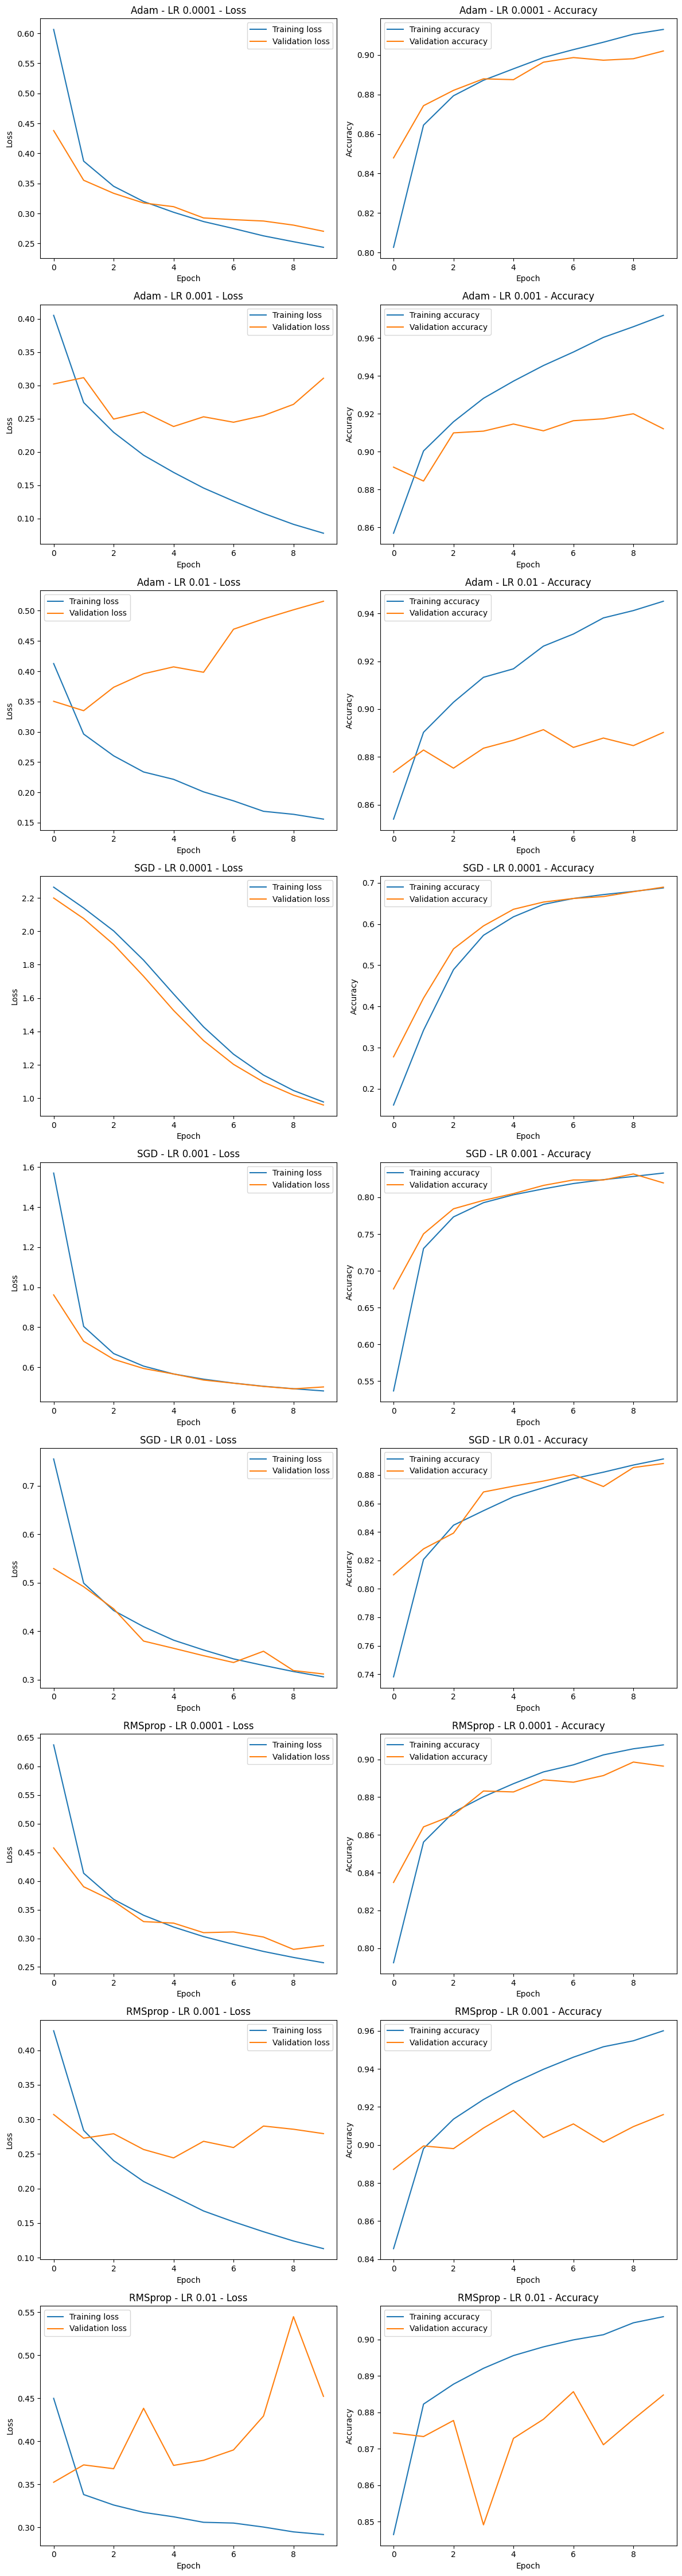

In [20]:
plot_all_histories(histories, titles)